# 🌌 Stellar Class — EDA
**Kaggle Playground Series S6E6**

Задача: классифицировать космические объекты на GALAXY / STAR / QSO

Метрика: Balanced Accuracy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
pd.set_option('display.max_columns', 50)

print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Загрузка данных

In [3]:
train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')
train.head()

Train: (577347, 12)
Test:  (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## 2. Базовая информация

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  str    
 10  galaxy_population  577347 non-null  str    
 11  class              577347 non-null  str    
dtypes: float64(8), int64(1), str(3)
memory usage: 52.9 MB


In [6]:
# Пропуски
missing = train.isnull().sum()
print('Пропуски в train:')
print(missing[missing > 0] if missing.any() else 'Пропусков нет ✅')

Пропуски в train:
Пропусков нет ✅


In [7]:
train.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


## 3. Распределение классов

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

Доля классов:
class
GALAXY    65.4
QSO       20.3
STAR      14.3
Name: count, dtype: float64


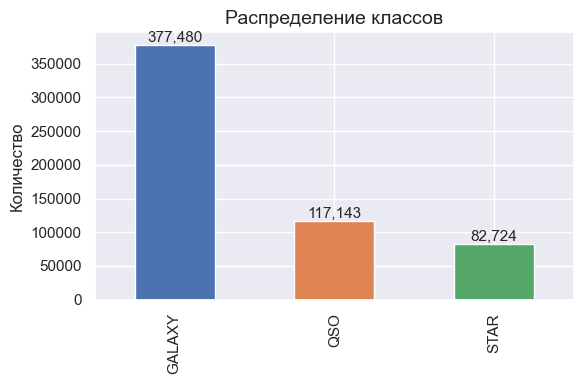

In [8]:
class_counts = train['class'].value_counts()
print(class_counts)
print('\nДоля классов:')
print((class_counts / len(train) * 100).round(1))

fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
ax.set_title('Распределение классов', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Количество')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Распределение ключевых фич

In [9]:
# Числовые колонки (без id)
num_cols = train.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'id']
print('Числовые фичи:', num_cols)

Числовые фичи: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


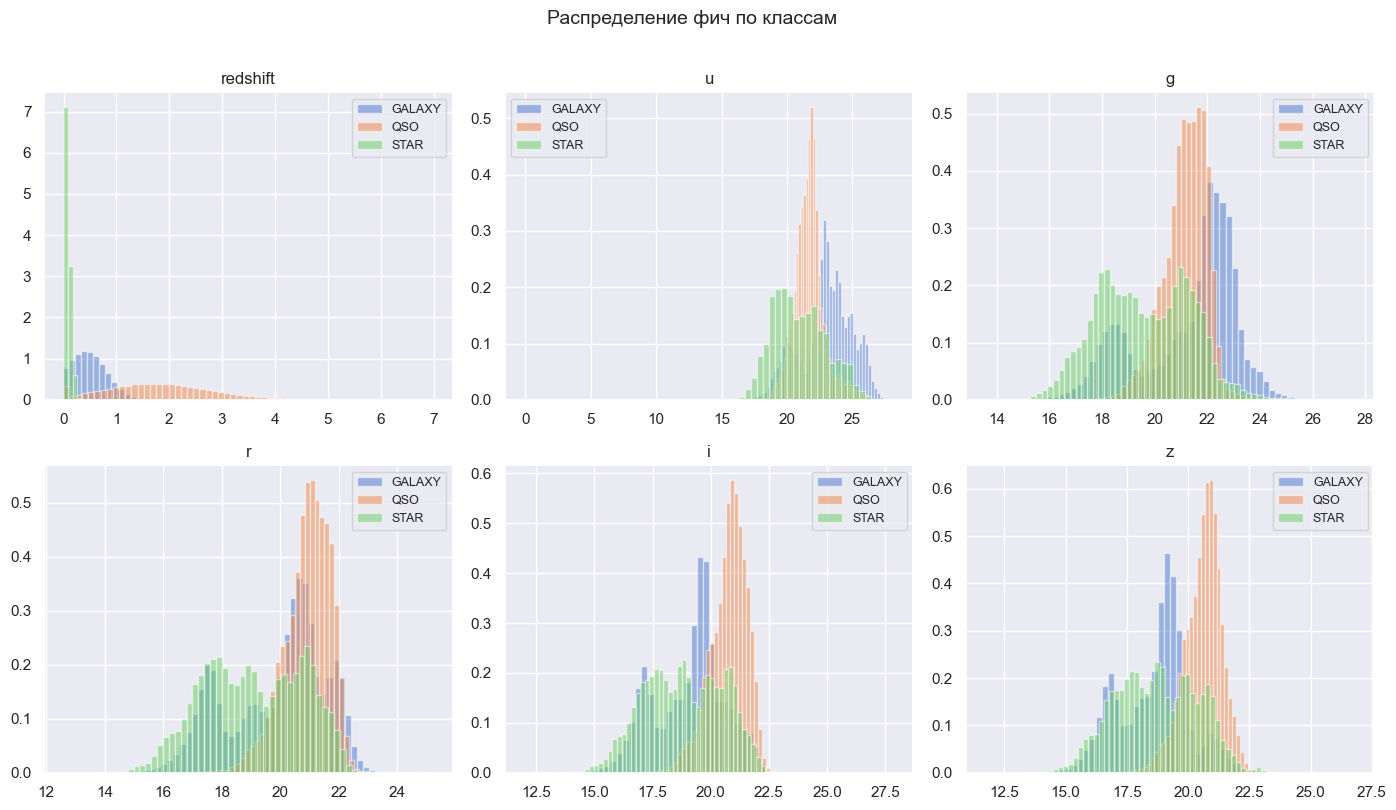

In [10]:
# Распределение числовых фич по классам
plot_cols = [c for c in ['redshift', 'u', 'g', 'r', 'i', 'z'] if c in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(plot_cols):
    for cls in train['class'].unique():
        subset = train[train['class'] == cls][col]
        axes[idx].hist(subset, bins=60, alpha=0.5, label=cls, density=True)
    axes[idx].set_title(col, fontsize=12)
    axes[idx].legend(fontsize=9)

plt.suptitle('Распределение фич по классам', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Redshift — главная переменная

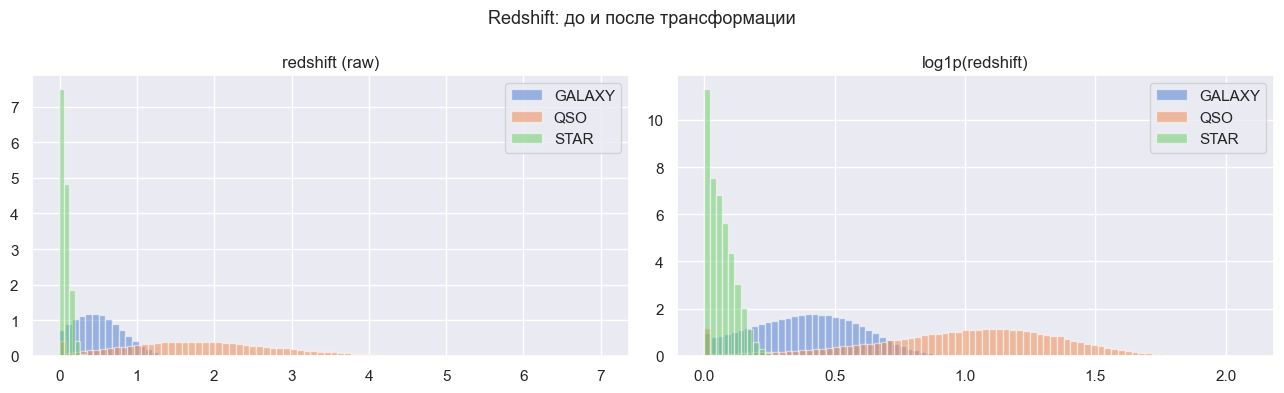

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Сырой redshift
for cls in train['class'].unique():
    axes[0].hist(train[train['class']==cls]['redshift'], bins=80, alpha=0.5, label=cls, density=True)
axes[0].set_title('redshift (raw)')
axes[0].legend()

# log1p redshift
for cls in train['class'].unique():
    vals = np.log1p(train[train['class']==cls]['redshift'].clip(lower=0))
    axes[1].hist(vals, bins=80, alpha=0.5, label=cls, density=True)
axes[1].set_title('log1p(redshift)')
axes[1].legend()

plt.suptitle('Redshift: до и после трансформации', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Корреляционная матрица

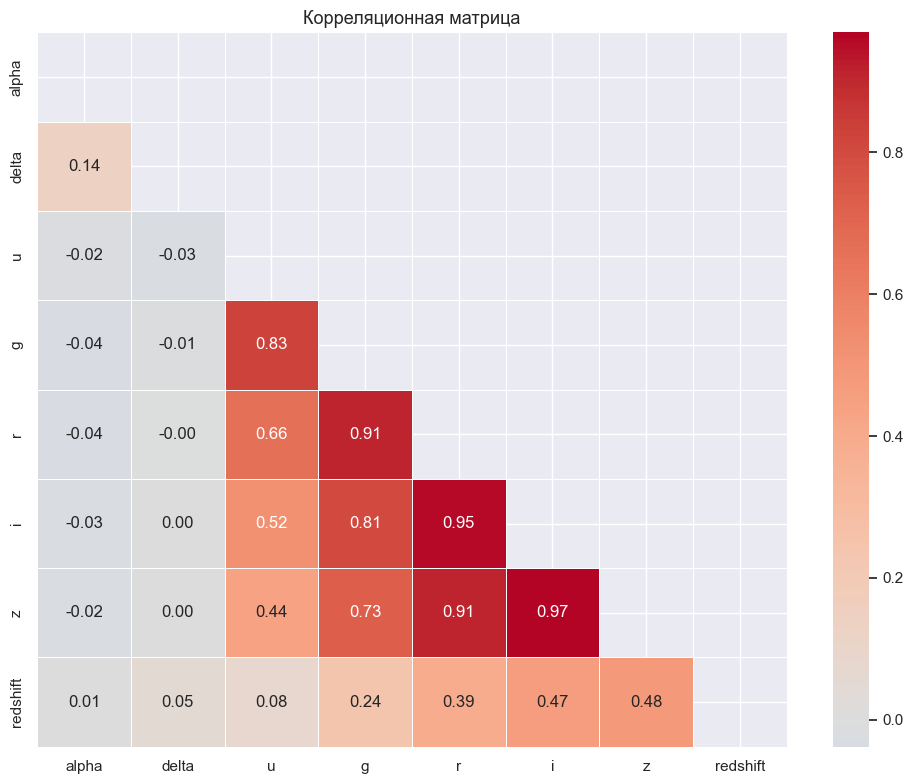

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Корреляционная матрица', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Цветовые индексы (u-g, g-r, r-i, i-z)

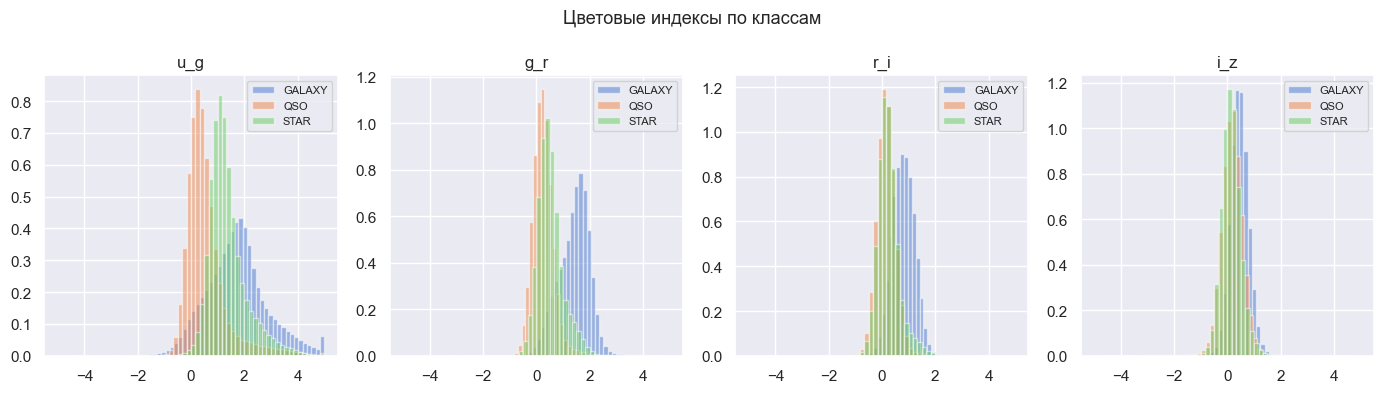

In [13]:
# Считаем цветовые индексы
for col_pair in [('u','g'), ('g','r'), ('r','i'), ('i','z')]:
    col_name = f'{col_pair[0]}_{col_pair[1]}'
    if col_pair[0] in train.columns and col_pair[1] in train.columns:
        train[col_name] = train[col_pair[0]] - train[col_pair[1]]

color_cols = [c for c in ['u_g','g_r','r_i','i_z'] if c in train.columns]

fig, axes = plt.subplots(1, len(color_cols), figsize=(14, 4))
for idx, col in enumerate(color_cols):
    for cls in train['class'].unique():
        vals = train[train['class']==cls][col].clip(-5, 5)
        axes[idx].hist(vals, bins=60, alpha=0.5, label=cls, density=True)
    axes[idx].set_title(col)
    axes[idx].legend(fontsize=8)

plt.suptitle('Цветовые индексы по классам', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Scatter plot: u_g vs redshift

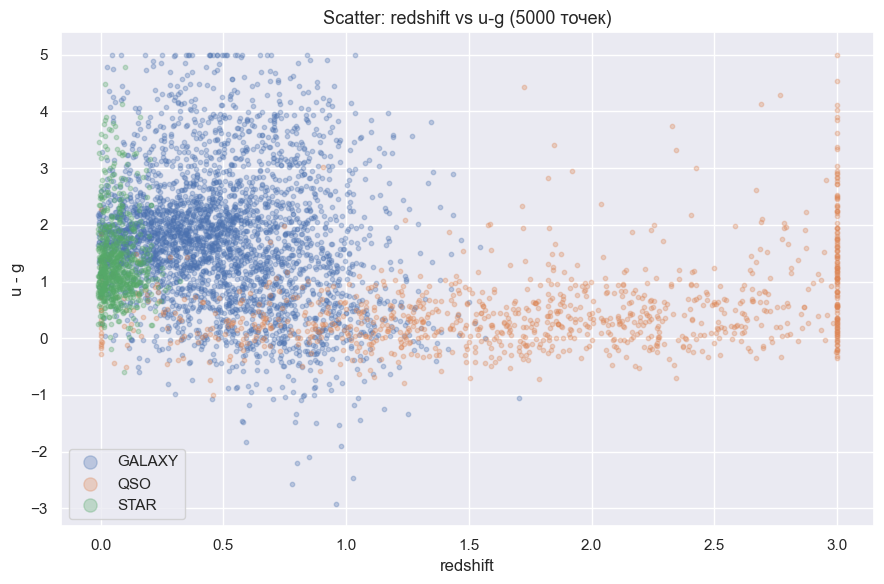

In [14]:
if 'u_g' in train.columns:
    sample = train.sample(5000, random_state=42)
    fig, ax = plt.subplots(figsize=(9, 6))
    colors = {'GALAXY': '#4C72B0', 'STAR': '#55A868', 'QSO': '#DD8452'}
    for cls, grp in sample.groupby('class'):
        ax.scatter(grp['redshift'].clip(-0.5, 3), grp['u_g'].clip(-3, 5),
                   alpha=0.3, s=10, label=cls, color=colors.get(cls))
    ax.set_xlabel('redshift')
    ax.set_ylabel('u - g')
    ax.set_title('Scatter: redshift vs u-g (5000 точек)', fontsize=13)
    ax.legend(markerscale=3)
    plt.tight_layout()
    plt.show()

## 9. Категориальные переменные

In [15]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'class']
print('Категориальные фичи:', cat_cols)

for col in cat_cols:
    print(f'\n{col}: {train[col].nunique()} уникальных значений')
    print(train[col].value_counts().head(10))

Категориальные фичи: ['spectral_type', 'galaxy_population']

spectral_type: 4 уникальных значений
spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

galaxy_population: 2 уникальных значений
galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_24088\2687675853.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns.tolist()


## 10. Выводы EDA

**Ключевые наблюдения:**
- `redshift` — главная разделяющая переменная между классами
- STAR имеет redshift близкий к 0, QSO — высокий, GALAXY — средний
- Цветовые индексы (u-g, g-r) хорошо разделяют STAR от остальных
- Дисбаланс классов есть → используем Balanced Accuracy как метрику

**Следующий шаг:** `02_baseline.ipynb` — обучаем первую LightGBM модель